In [67]:
from matplotlib.lines import lineStyles
from pyparsing import line
from sklearn.datasets import make_classification

In [68]:
num_features = 10

X,y = make_classification(
    n_samples=300,
    n_features=num_features,
    n_informative=5,
    n_redundant=3,
    random_state=42
)

In [69]:
import numpy as np
#
# X = np.transpose(X)


In [70]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [71]:
scaler.fit(X)

X = scaler.transform(X)

In [72]:
from sklearn.decomposition import TruncatedSVD

components= np.arange(1,num_features)

variances = []


for component in components:

    svd = TruncatedSVD(n_components=component)
    svd.fit(X)

    variance = np.sum(svd.explained_variance_ratio_)
    variances.append(variance)


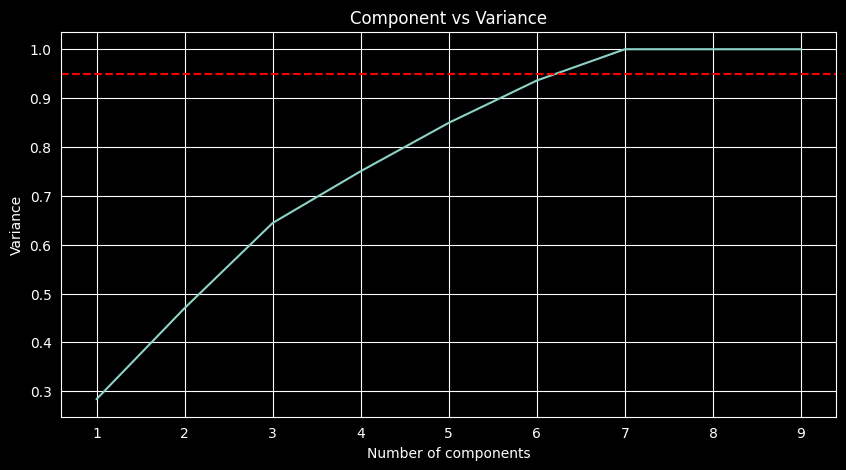

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10,5))
sns.lineplot(x=components , y=variances)
plt.axhline(y=0.95 , linestyle='--' ,color='red')
plt.xlabel("Number of components")
plt.ylabel("Variance")
plt.title("Component vs Variance")
plt.show()

In [74]:


svd = TruncatedSVD(n_components=6)
svd.fit(X)

,"n_components n_components: int, default=2Desired dimensionality of output data.If algorithm='arpack', must be strictly less than the number of features.If algorithm='randomized', must be less than or equal to the number of features.The default value is useful for visualisation. For LSA, a value of100 is recommended.",6
,"algorithm algorithm: {'arpack', 'randomized'}, default='randomized'SVD solver to use. Either ""arpack"" for the ARPACK wrapper in SciPy(scipy.sparse.linalg.svds), or ""randomized"" for the randomizedalgorithm due to Halko (2009).",'randomized'
,"n_iter n_iter: int, default=5Number of iterations for randomized SVD solver. Not used by ARPACK. Thedefault is larger than the default in:func:`~sklearn.utils.extmath.randomized_svd` to handle sparsematrices that may have large slowly decaying spectrum.",5
,"n_oversamples n_oversamples: int, default=10Number of oversamples for randomized SVD solver. Not used by ARPACK.See :func:`~sklearn.utils.extmath.randomized_svd` for a completedescription... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD solver.Not used by ARPACK. See :func:`~sklearn.utils.extmath.randomized_svd`for more details... versionadded:: 1.1",'auto'
,"random_state random_state: int, RandomState instance or None, default=NoneUsed during randomized svd. Pass an int for reproducible results acrossmultiple function calls.See :term:`Glossary `.",None
,"tol tol: float, default=0.0Tolerance for ARPACK. 0 means machine precision. Ignored by randomizedSVD solver.",0.0


In [75]:
X_svd = svd.transform(X)

In [76]:
X_svd.shape

(300, 6)

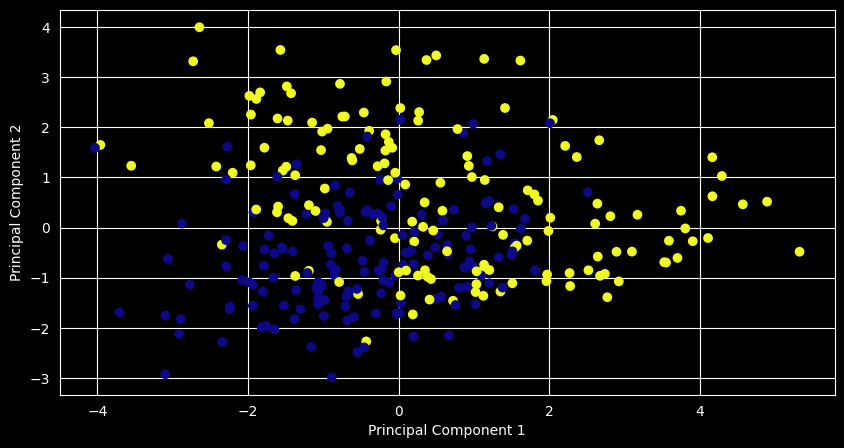

In [77]:
plt.figure(figsize=(10,5))
plt.scatter(X_svd[:,0], X_svd[:,1], c=y , cmap='plasma')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()